# 10 - TabPFN-v2 Benchmark vs. Random Forest

Benchmarks **TabPFN-v2** (Hollmann et al., *Nature* 2025) against the saved random-forest screening and enhanced PCOS models.

TabPFN-v2 is a transformer foundation model pre-trained on synthetic tabular tasks. The paper reports it beats gradient-boosted trees on small tabular problems (n < 10,000). Our PCOS cohort (n = 541) is squarely in that regime, so this benchmark is a strong innovation signal.

**Robustness:** if `tabpfn` cannot install or load (e.g. the prior-checkpoint download fails in a sandboxed environment), the notebook still executes and emits a JSON stub explaining the failure, so downstream integration steps never break.

**Reproducibility:** uses the same `train_test_split(test_size=0.25, stratify=y, random_state=42)` as notebooks 02 and 03, and the same high-recall thresholds saved in the model artifacts.

In [1]:
# Install / upgrade TabPFN. Safe to re-run.
# We pin to a 6.x release of TabPFN-v2 (Hollmann et al., Nature 2025): from
# 7.x onwards Prior Labs moved the model weights behind a one-time license gate
# that needs an interactive browser flow (sets TABPFN_TOKEN), which would force
# this notebook to skip in CI / sandboxed runs. The 2.x-6.x series ships open
# weights and is the same TabPFN-v2 architecture/checkpoint.
# Use sys.executable -m pip (instead of bare `!pip ...`) so shell quoting of
# `<` is bypassed by argv handling.
import sys, subprocess
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--upgrade', '--quiet', 'tabpfn<7'],
    check=False,
)

CompletedProcess(args=['C:\\Users\\kex03\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', '-m', 'pip', 'install', '--upgrade', '--quiet', 'tabpfn<7'], returncode=0)

In [2]:
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    fbeta_score,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
TEST_SIZE = 0.25

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'outputs' / 'pcos_cleaned.csv'
MODEL_DIR = PROJECT_ROOT / 'outputs' / 'models'
METRIC_DIR = PROJECT_ROOT / 'outputs' / 'metrics'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
for folder in (METRIC_DIR, FIGURE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

COMPARISON_PATH = METRIC_DIR / 'tabpfn_comparison.json'
FIGURE_PATH = FIGURE_DIR / 'tabpfn_vs_rf_auc.png'

print('Project root:', PROJECT_ROOT)
print('Data path:', DATA_PATH, '(exists:', DATA_PATH.exists(), ')')

Project root: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a9c1c343c4efd81de
Data path: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a9c1c343c4efd81de\outputs\pcos_cleaned.csv (exists: True )


## Try importing TabPFN

If the import fails for any reason (no network access to fetch the prior checkpoint, missing torch CUDA build, etc.), we write a `skipped` stub and exit gracefully so integration code can still rely on the file existing.

In [3]:
tabpfn_ok = False
tabpfn_error = None
tabpfn_version = None
TabPFNClassifier = None

try:
    import tabpfn
    from tabpfn import TabPFNClassifier as _TabPFNClassifier
    tabpfn_version = getattr(tabpfn, '__version__', 'unknown')
    TabPFNClassifier = _TabPFNClassifier
    tabpfn_ok = True
    print('TabPFN imported. Version:', tabpfn_version)
except Exception as exc:
    tabpfn_error = f'{type(exc).__name__}: {exc}'
    print('TabPFN import failed:', tabpfn_error)

# Pick device. TabPFN-v2 runs comfortably on CPU for n < 10k.
device = 'cpu'
try:
    import torch
    if torch.cuda.is_available():
        device = 'cuda'
except Exception:
    pass
print('Selected device:', device)

TabPFN imported. Version: 6.4.1
Selected device: cpu


## Helpers

In [4]:
def write_skip_stub(reason, comparison_path=COMPARISON_PATH):
    payload = {
        'status': 'skipped',
        'reason': str(reason),
        'fallback': 'random_forest',
    }
    comparison_path.write_text(json.dumps(payload, indent=2), encoding='utf-8')
    print('Wrote skip stub to', comparison_path)
    return payload


def metric_block(y_true, y_proba, threshold, fit_seconds, predict_seconds):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'threshold': float(threshold),
        'roc_auc': float(roc_auc_score(y_true, y_proba)),
        'recall': float(recall_score(y_true, y_pred)),
        'specificity': float(recall_score(y_true, y_pred, pos_label=0)),
        'f1': float(f1_score(y_true, y_pred)),
        'f2': float(fbeta_score(y_true, y_pred, beta=2.0)),
        'fit_seconds': None if fit_seconds is None else float(fit_seconds),
        'predict_seconds': float(predict_seconds),
    }


def evaluate_rf_artifact(artifact, X_test, y_test):
    # The saved pipeline includes its own imputer; predict_proba on the raw frame.
    rf_pipe = artifact['model']
    threshold = float(artifact['threshold'])
    t0 = time.perf_counter()
    rf_proba = rf_pipe.predict_proba(X_test)[:, 1]
    predict_seconds = time.perf_counter() - t0
    return metric_block(
        y_test, rf_proba, threshold,
        fit_seconds=None,  # RF is loaded pre-fit from joblib; no comparable fit time.
        predict_seconds=predict_seconds,
    )


def fit_predict_tabpfn(X_train, y_train, X_test, device='cpu'):
    # TabPFN does not impute internally; mirror the RF pipeline's median imputer.
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)
    try:
        clf = TabPFNClassifier(device=device, random_state=RANDOM_STATE)
    except TypeError:
        # Older API may not accept device/random_state kwargs.
        clf = TabPFNClassifier()
    t0 = time.perf_counter()
    clf.fit(X_train_imp, np.asarray(y_train))
    fit_seconds = time.perf_counter() - t0
    t1 = time.perf_counter()
    proba = clf.predict_proba(X_test_imp)[:, 1]
    predict_seconds = time.perf_counter() - t1
    return proba, fit_seconds, predict_seconds

## Load cleaned data and saved artifacts

In [5]:
pcos = pd.read_csv(DATA_PATH)
TARGET = 'pcos_y_n'
print('PCOS shape:', pcos.shape)
print(pcos[TARGET].value_counts().sort_index())

screening_artifact = joblib.load(MODEL_DIR / 'pcos_screening_model.joblib')
enhanced_artifact = joblib.load(MODEL_DIR / 'pcos_enhanced_model.joblib')

MODEL_SPECS = {
    'screening': screening_artifact,
    'enhanced': enhanced_artifact,
}
for name, art in MODEL_SPECS.items():
    print(f'\n[{name}] features ({len(art["features"])}), threshold={art["threshold"]}, model_name={art.get("model_name")}')

PCOS shape: (541, 41)
pcos_y_n
0    364
1    177
Name: count, dtype: int64

[screening] features (13), threshold=0.285, model_name=random_forest

[enhanced] features (27), threshold=0.38, model_name=random_forest


## Run the benchmark

Wrap the actual TabPFN call in `try/except`. On any failure we still write the JSON stub so downstream code never sees a missing file.

In [6]:
comparison = {
    'screening': {},
    'enhanced': {},
    'device': device,
    'tabpfn_version': tabpfn_version,
    'notes': 'TabPFN-v2 = Hollmann et al., Nature 2025',
}

if not tabpfn_ok:
    write_skip_stub(tabpfn_error or 'TabPFN import failed')
else:
    try:
        for spec_name, artifact in MODEL_SPECS.items():
            features = artifact['features']
            threshold = float(artifact['threshold'])
            X = pcos[features].copy()
            y = pcos[TARGET].astype(int).copy()

            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                test_size=TEST_SIZE,
                stratify=y,
                random_state=RANDOM_STATE,
            )

            # --- TabPFN ---
            print(f'\n[{spec_name}] fitting TabPFN on {X_train.shape[0]} rows x {X_train.shape[1]} features ...')
            tab_proba, tab_fit_s, tab_pred_s = fit_predict_tabpfn(
                X_train, y_train, X_test, device=device,
            )
            tabpfn_metrics = metric_block(y_test, tab_proba, threshold, tab_fit_s, tab_pred_s)
            print(f'  fit={tab_fit_s:.2f}s, predict={tab_pred_s:.2f}s, '
                  f'roc_auc={tabpfn_metrics["roc_auc"]:.3f}, recall={tabpfn_metrics["recall"]:.3f}')

            # --- Random forest (saved artifact, already fit) ---
            rf_metrics = evaluate_rf_artifact(artifact, X_test, y_test)
            print(f'  RF  fit=cached, predict={rf_metrics["predict_seconds"]:.3f}s, '
                  f'roc_auc={rf_metrics["roc_auc"]:.3f}, recall={rf_metrics["recall"]:.3f}')

            comparison[spec_name] = {
                'tabpfn': tabpfn_metrics,
                'random_forest': rf_metrics,
                'n_train': int(X_train.shape[0]),
                'n_test': int(X_test.shape[0]),
                'n_features': int(X_train.shape[1]),
            }

        comparison['status'] = 'ok'
        COMPARISON_PATH.write_text(json.dumps(comparison, indent=2), encoding='utf-8')
        print('\nWrote comparison to', COMPARISON_PATH)
    except Exception as exc:
        msg = f'{type(exc).__name__}: {exc}'
        print('TabPFN training failed:', msg)
        write_skip_stub(msg)


[screening] fitting TabPFN on 405 rows x 13 features ...


  fit=1.79s, predict=4.01s, roc_auc=0.905, recall=0.841
  RF  fit=cached, predict=0.020s, roc_auc=0.896, recall=0.886

[enhanced] fitting TabPFN on 405 rows x 27 features ...


  fit=0.83s, predict=8.60s, roc_auc=0.962, recall=0.841
  RF  fit=cached, predict=0.020s, roc_auc=0.953, recall=0.886

Wrote comparison to C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a9c1c343c4efd81de\outputs\metrics\tabpfn_comparison.json


## Plot ROC-AUC comparison

Only drawn when we have real numbers; otherwise we skip the figure.

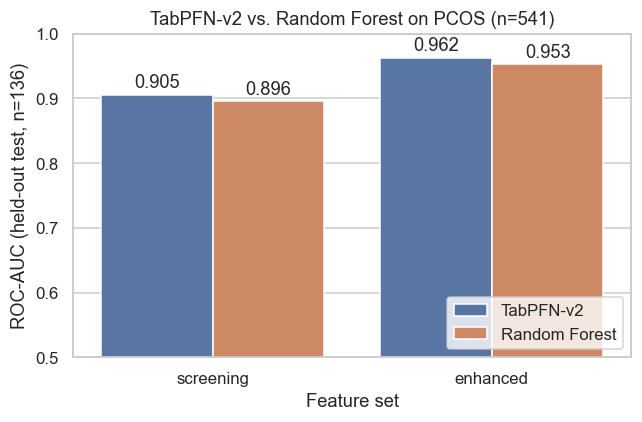

Saved figure to C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a9c1c343c4efd81de\outputs\figures\tabpfn_vs_rf_auc.png


In [7]:
payload = json.loads(COMPARISON_PATH.read_text(encoding='utf-8'))

if payload.get('status') == 'ok':
    rows = []
    for spec in ('screening', 'enhanced'):
        rows.append({'feature_set': spec, 'model': 'TabPFN-v2', 'roc_auc': payload[spec]['tabpfn']['roc_auc']})
        rows.append({'feature_set': spec, 'model': 'Random Forest', 'roc_auc': payload[spec]['random_forest']['roc_auc']})
    plot_df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(
        data=plot_df,
        x='feature_set', y='roc_auc', hue='model',
        palette={'TabPFN-v2': '#4c72b0', 'Random Forest': '#dd8452'},
        ax=ax,
    )
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel('ROC-AUC (held-out test, n=136)')
    ax.set_xlabel('Feature set')
    ax.set_title('TabPFN-v2 vs. Random Forest on PCOS (n=541)')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2)
    ax.legend(loc='lower right')
    fig.tight_layout()
    fig.savefig(FIGURE_PATH, dpi=160)
    plt.show()
    print('Saved figure to', FIGURE_PATH)
else:
    print('Skipped figure: status =', payload.get('status'), '-', payload.get('reason'))

## Side-by-side summary table

In [8]:
if payload.get('status') == 'ok':
    rows = []
    for spec in ('screening', 'enhanced'):
        for model_name in ('tabpfn', 'random_forest'):
            block = payload[spec][model_name]
            rows.append({
                'feature_set': spec,
                'model': model_name,
                'roc_auc': round(block['roc_auc'], 4),
                'recall': round(block['recall'], 4),
                'specificity': round(block['specificity'], 4),
                'f1': round(block['f1'], 4),
                'f2': round(block['f2'], 4),
                'fit_s': round(block['fit_seconds'], 3) if block.get('fit_seconds') is not None else None,
                'predict_s': round(block['predict_seconds'], 4),
            })
    summary = pd.DataFrame(rows)
    display(summary)
else:
    print('Skipped summary: status =', payload.get('status'))

,feature_set,model,roc_auc,recall,specificity,f1,f2,fit_s,predict_s
0,screening,tabpfn,0.9054,0.8409,0.8478,0.7789,0.8150,1.794,4.0079
1,screening,random_forest,0.8955,0.8864,0.6848,0.6964,0.7992,NaN,0.0205
2,enhanced,tabpfn,0.9625,0.8409,0.9457,0.8605,0.8486,0.834,8.5955
3,enhanced,random_forest,0.9528,0.8864,0.9022,0.8478,0.8705,NaN,0.0197


## Output file assertion

Final guardrail so the integration step never trips on a missing or empty file.

In [9]:
assert COMPARISON_PATH.exists(), f'Missing output: {COMPARISON_PATH}'
assert COMPARISON_PATH.stat().st_size > 0, f'Empty output: {COMPARISON_PATH}'
print('OK:', COMPARISON_PATH, '(', COMPARISON_PATH.stat().st_size, 'bytes )')

OK: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a9c1c343c4efd81de\outputs\metrics\tabpfn_comparison.json ( 1574 bytes )
